In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns 
from datetime import datetime

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
data = pd.ExcelFile("phonepe.xlsx")
data.sheet_names

['State_Txn and Users',
 'State_TxnSplit',
 'State_DeviceData',
 'District_Txn and Users',
 'District Demographics',
 'Admin']

# Task 1. Data Loading and understanding

In [4]:
# 1.1 Loaded each dataset and its structure

In [5]:
txn_sheet = pd.read_excel(data, "State_Txn and Users")
txn_sheet.head(5)


,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [6]:
txn_sheet.dtypes

State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

In [7]:

txn_sheet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             504 non-null    object 
 1   Year              504 non-null    int64  
 2   Quarter           504 non-null    int64  
 3   Transactions      504 non-null    int64  
 4   Amount (INR)      503 non-null    float64
 5   ATV (INR)         504 non-null    float64
 6   Registered Users  504 non-null    int64  
 7   App Opens         504 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 31.6+ KB


In [8]:
# find out where null present.

txn_sheet[txn_sheet["Amount (INR)"].isnull()]

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,NaN,0.0,18363733,957709447


In [9]:
#2.	Load the State_TxnSplit dataset and display its bottom 10 rows.

txnsplit_sheet = pd.read_excel(data, "State_TxnSplit")
txnsplit_sheet.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


In [10]:
txnsplit_sheet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             2514 non-null   object 
 1   Year              2514 non-null   int64  
 2   Quarter           2514 non-null   int64  
 3   Transaction Type  2514 non-null   object 
 4   Transactions      2514 non-null   int64  
 5   Amount (INR)      2514 non-null   float64
 6   ATV (INR)         2514 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 137.6+ KB


In [11]:
# 3. Load the State_DeviceData dataset and display 10 rows from the middle of the dataset.

device_sheet = pd.read_excel(data, "State_DeviceData")
middle_idx = len(device_sheet)//2
device_sheet.iloc[middle_idx -5 : middle_idx + 5]


,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


In [12]:
device_sheet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             5544 non-null   object 
 1   Year              5544 non-null   int64  
 2   Quarter           5544 non-null   int64  
 3   Brand             5544 non-null   object 
 4   Registered Users  5544 non-null   int64  
 5   Percentage        5544 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 260.0+ KB


In [13]:
# 4.	Load the District_Txn and Users dataset and display its first 10 rows and last 10 rows.

district_txn_sheet = pd.read_excel(data, "District_Txn and Users")
print(f"First 10 rows")
district_txn_sheet.head(10)
print(f"Last 10 Rows")
district_txn_sheet.tail(10)


First 10 rows


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


Last 10 Rows


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


In [14]:
district_txn_sheet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10248 entries, 0 to 10247
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             10248 non-null  object 
 1   Year              10248 non-null  int64  
 2   Quarter           10248 non-null  int64  
 3   District          10248 non-null  object 
 4   Code              10220 non-null  object 
 5   Transactions      10248 non-null  int64  
 6   Amount (INR)      10248 non-null  float64
 7   ATV (INR)         10244 non-null  float64
 8   Registered Users  10248 non-null  int64  
 9   App Opens         10248 non-null  int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 800.8+ KB


In [15]:

district_txn_sheet[district_txn_sheet["Code"].isnull()].head()
print("Jammu & Kashmir where Code are null")

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
3133,Jammu & Kashmir,2018,1,Mirpur,NaN,1320,3.052182e+06,2312.259022,544,0
3134,Jammu & Kashmir,2018,1,Muzaffarabad,NaN,13,1.455980e+04,1119.984877,41,0
3155,Jammu & Kashmir,2018,2,Mirpur,NaN,1885,4.089199e+06,2169.336200,795,0
3156,Jammu & Kashmir,2018,2,Muzaffarabad,NaN,75,3.688235e+05,4917.646448,57,0
3177,Jammu & Kashmir,2018,3,Mirpur,NaN,2789,7.804798e+06,2798.421577,1133,0


Jammu & Kashmir where Code are null


In [16]:
# 5.	Load the District Demographics dataset and display every 10th row.

district_sheet = pd.read_excel(data, "District Demographics")
district_sheet.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


In [17]:
district_sheet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           742 non-null    object 
 1   District        742 non-null    object 
 2   Headquarters    742 non-null    object 
 3   Population      742 non-null    int64  
 4   Area (sq km)    742 non-null    float64
 5   Density         742 non-null    int64  
 6   Code            742 non-null    object 
 7   Alternate Name  742 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 46.5+ KB


## Checking for missing values

In [18]:
txn_sheet.isnull().sum()

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64

In [19]:
null = txn_sheet.isnull().any(axis = 1)
null[null].index

Index([26], dtype='int64')

In [20]:
null = txn_sheet.isnull().sum()
null_per = (null/len(txn_sheet))*100
print(f" Missing values in percentages")
null_per

 Missing values in percentages


State               0.000000
Year                0.000000
Quarter             0.000000
Transactions        0.000000
Amount (INR)        0.198413
ATV (INR)           0.000000
Registered Users    0.000000
App Opens           0.000000
dtype: float64

In [21]:
txnsplit_sheet.isnull().sum()

State               0
Year                0
Quarter             0
Transaction Type    0
Transactions        0
Amount (INR)        0
ATV (INR)           0
dtype: int64

In [22]:
device_sheet.isnull().sum()

State               0
Year                0
Quarter             0
Brand               0
Registered Users    0
Percentage          0
dtype: int64

In [23]:
district_txn_sheet.isnull().sum()

State                0
Year                 0
Quarter              0
District             0
Code                28
Transactions         0
Amount (INR)         0
ATV (INR)            4
Registered Users     0
App Opens            0
dtype: int64

In [24]:
null = district_txn_sheet.isnull().sum()
null_per = (null/len(district_txn_sheet))*100
print(f" Missing values in percentages")
print(null_per)

print(null_per.max())

 Missing values in percentages
State               0.000000
Year                0.000000
Quarter             0.000000
District            0.000000
Code                0.273224
Transactions        0.000000
Amount (INR)        0.000000
ATV (INR)           0.039032
Registered Users    0.000000
App Opens           0.000000
dtype: float64
0.273224043715847


In [25]:
district_txn_sheet[district_txn_sheet["ATV (INR)"].isnull()]

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
224,Arunachal Pradesh,2018,1,Anjaw,AR01,0,0.0,NaN,278,0
241,Arunachal Pradesh,2018,1,Shi Yomi,AR17,0,0.0,NaN,49,0
266,Arunachal Pradesh,2018,2,Shi Yomi,AR17,0,0.0,NaN,80,0
291,Arunachal Pradesh,2018,3,Shi Yomi,AR17,0,0.0,NaN,118,0


In [26]:
district_sheet.isnull().sum()

State             0
District          0
Headquarters      0
Population        0
Area (sq km)      0
Density           0
Code              0
Alternate Name    0
dtype: int64

#### 1. In district_transaction_sheet have  28 null values in "Code" column and 4 null values in ATV (INR) column.
#### 2. In State_transaction_sheet have 1 null values in " Amount (VAT)" column

In [27]:
# 1.	Calculate the total number of states and the total number of districts.

total_state = district_sheet["State"].nunique()

print(f"Total States including union territories: {total_state}")

total_district = district_sheet["District"].nunique()

print(f"Total number of district: {total_district}")


Total States including union territories: 36
Total number of district: 736


In [28]:
# 2.	Identify the state with the highest number of districts. 

state_count = district_sheet["State"].value_counts()
district_max_state = state_count.idxmax()
no_count = state_count.max()
print(f"State with highest number of district: {district_max_state} which is {no_count} districts.")

State with highest number of district: Uttar Pradesh which is 75 districts.


# Task 2: Exploratory Data Analysis (EDA)

#### 2.1: Analyze transaction trends over the years for each state

In [29]:
# 1. Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.

txn_sheet.columns

Index(['State', 'Year', 'Quarter', 'Transactions', 'Amount (INR)', 'ATV (INR)',
       'Registered Users', 'App Opens'],
      dtype='object')

In [30]:
print(f"Total number of transaction and total tramsaction amount for each state over the year")
txn_sheet.groupby(["State","Year"])[["Transactions","Amount (INR)"]].sum()

Total number of transaction and total tramsaction amount for each state over the year


Transactions  Amount (INR)
State                     Year                            
Andaman & Nicobar Islands 2018         58021  1.890761e+08
                          2019        133104  4.734648e+08
                          2020        446274  1.296423e+09
                          2021        586166  1.682854e+09
Andhra Pradesh            2018      77779112  1.220720e+11
...                                      ...           ...
Uttarakhand               2021      44608834  7.727901e+10
West Bengal               2018     120011635  1.115887e+11
                          2019     257900590  2.660145e+11
                          2020     304222327  5.527316e+11
                          2021     260151489  5.223720e+11

[144 rows x 2 columns]

In [31]:
# 2. Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.

In [32]:
print(f"Top 5 states with highest transaction volumes")

txn_sheet.groupby("State")["Transactions"].sum().nlargest(5).reset_index()

Top 5 states with highest transaction volumes


,State,Transactions
0,Karnataka,2981044533
1,Maharashtra,2833670154
2,Telangana,2347430243
3,Andhra Pradesh,1781091169
4,Rajasthan,1382918930


In [33]:
print(f"Top 5 states with smallest transaction volumes")

txn_sheet.groupby("State")["Transactions"].sum().nsmallest(5).reset_index()

Top 5 states with smallest transaction volumes


,State,Transactions
0,Lakshadweep,71610
1,Andaman & Nicobar Islands,1223565
2,Ladakh,1880109
3,Mizoram,2162776
4,Meghalaya,5648913


### 2.2: Identify the most common transaction types in each state and quarter

In [34]:
# 1.For each state and quarter, determine the most frequent transaction type. Display the results in a tabular format.

In [35]:
txnsplit_sheet[txnsplit_sheet["State"] == "West Bengal"].reset_index()

,index,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,2444,West Bengal,2018,1,Recharge & bill payments,5773831,9.643095e+08,167.013805
1,2445,West Bengal,2018,1,Peer-to-peer payments,4383075,8.874267e+09,2024.666889
2,2446,West Bengal,2018,1,Financial Services,665171,1.195023e+08,179.656467
3,2447,West Bengal,2018,1,Merchant payments,443378,3.667887e+08,827.259584
4,2448,West Bengal,2018,1,Others,444770,3.011113e+08,677.004449
...,...,...,...,...,...,...,...,...
65,2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
66,2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
67,2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
68,2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630


In [36]:
new_result = txnsplit_sheet.loc[txnsplit_sheet.groupby(["State","Quarter"])["Transactions"].idxmax()]

new_result[["State", "Year", "Quarter", "Transaction Type", "Transactions"]].sort_index()

,State,Year,Quarter,Transaction Type,Transactions
50,Andaman & Nicobar Islands,2020,3,Recharge & bill payments,59310
55,Andaman & Nicobar Islands,2020,4,Peer-to-peer payments,81439
60,Andaman & Nicobar Islands,2021,1,Peer-to-peer payments,105458
65,Andaman & Nicobar Islands,2021,2,Peer-to-peer payments,132772
120,Andhra Pradesh,2020,3,Peer-to-peer payments,106791894
...,...,...,...,...,...
2439,Uttar Pradesh,2021,2,Peer-to-peer payments,102927942
2454,West Bengal,2018,3,Peer-to-peer payments,41882429
2479,West Bengal,2019,4,Peer-to-peer payments,67037576
2504,West Bengal,2021,1,Peer-to-peer payments,53869075


### 2.3: Determine the device brand with the highest number of registered users in each state

In [37]:
# 1.	Identify the device brand with the highest number of registered users in each state. Display the results in a tabular format.

In [38]:
brand_col = device_sheet.groupby(["Brand","State"])["Registered Users"].sum().reset_index()

each_state_brand = brand_col.loc[brand_col.groupby("State")["Registered Users"].idxmax()]

print("Each State of device brand name with highest users")
each_state_brand.reset_index()

Each State of device brand name with highest users


,index,Brand,State,Registered Users
0,412,Xiaomi,Andaman & Nicobar Islands,97889
1,413,Xiaomi,Andhra Pradesh,40061549
2,414,Xiaomi,Arunachal Pradesh,437803
3,415,Xiaomi,Assam,6979357
4,416,Xiaomi,Bihar,33721314
5,417,Xiaomi,Chandigarh,896628
6,418,Xiaomi,Chhattisgarh,8763373
7,419,Xiaomi,Dadra & Nagar Haveli and Daman & Diu,638834
8,420,Xiaomi,Delhi,24114984
9,421,Xiaomi,Goa,1208672


### 2.4: Create a list of the top district per state based on population

In [39]:
# 1.	For each state, identify the district with the highest population. Display the results in a tabular format.

In [40]:
dis_count = district_sheet.groupby(["State", "District"])["Population"].sum().reset_index()

top_dis = dis_count.loc[dis_count.groupby("State")["Population"].idxmax()]
top_dis.sort_index()

,State,District,Population
2,Andaman & Nicobar Islands,South Andaman,238142
5,Andhra Pradesh,East Godavari,5151549
31,Arunachal Pradesh,Papum Pare,176385
67,Assam,Nagaon,2826006
100,Bihar,Patna,5772804
113,Chandigarh,Chandigarh,1055450
137,Chhattisgarh,Raipur,2160876
142,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709
150,Delhi,North West Delhi,3656539
156,Goa,North Goa,817761


 2.	Create a column chart depicting the district with the highest population for each state.

<Figure size 1400x800 with 0 Axes>

Text(0.5, 1.0, 'Top District by Population in Each State')

Text(0.5, 0, 'State')

Text(0, 0.5, 'Population')

Text(0.0, 240523.42, 'South Andaman')

...

Text(32.0, 926709.34, 'West Tripura')

Text(33.0, 6019395.98, 'Allahabad')

Text(34.0, 1946299.29, 'Haridwar')

Text(35.0, 10183680.52, 'North 24 Parganas')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'Andaman & Nicobar Islands'),
  Text(1, 0, 'Andhra Pradesh'),
  Text(2, 0, 'Arunachal Pradesh'),
  Text(3, 0, 'Assam'),
  Text(4, 0, 'Bihar'),
  Text(5, 0, 'Chandigarh'),
  Text(6, 0, 'Chhattisgarh'),
  Text(7, 0, 'Dadra & Nagar Haveli and Daman & Diu'),
  Text(8, 0, 'Delhi'),
  Text(9, 0, 'Goa'),
  Text(10, 0, 'Gujarat'),
  Text(11, 0, 'Haryana'),
  Text(12, 0, 'Himachal Pradesh'),
  Text(13, 0, 'Jammu & Kashmir'),
  Text(14, 0, 'Jharkhand'),
  Text(15, 0, 'Karnataka'),
  Text(16, 0, 'Kerala'),
  Text(17, 0, 'Ladakh'),
  Text(18, 0, 'Lakshadweep'),
  Text(19, 0, 'Madhya Pradesh'),
  Text(20, 0, 'Maharashtra'),
  Text(21, 0, 'Manipur'),
  Text(22, 0, 'Meghalaya'),
  Text(23, 0, 'Mizoram'),
  Text(24, 0, 'Nagaland'),
  Text(25, 0, 'Odisha'),
  Text(26, 0, 'Puducherry'),


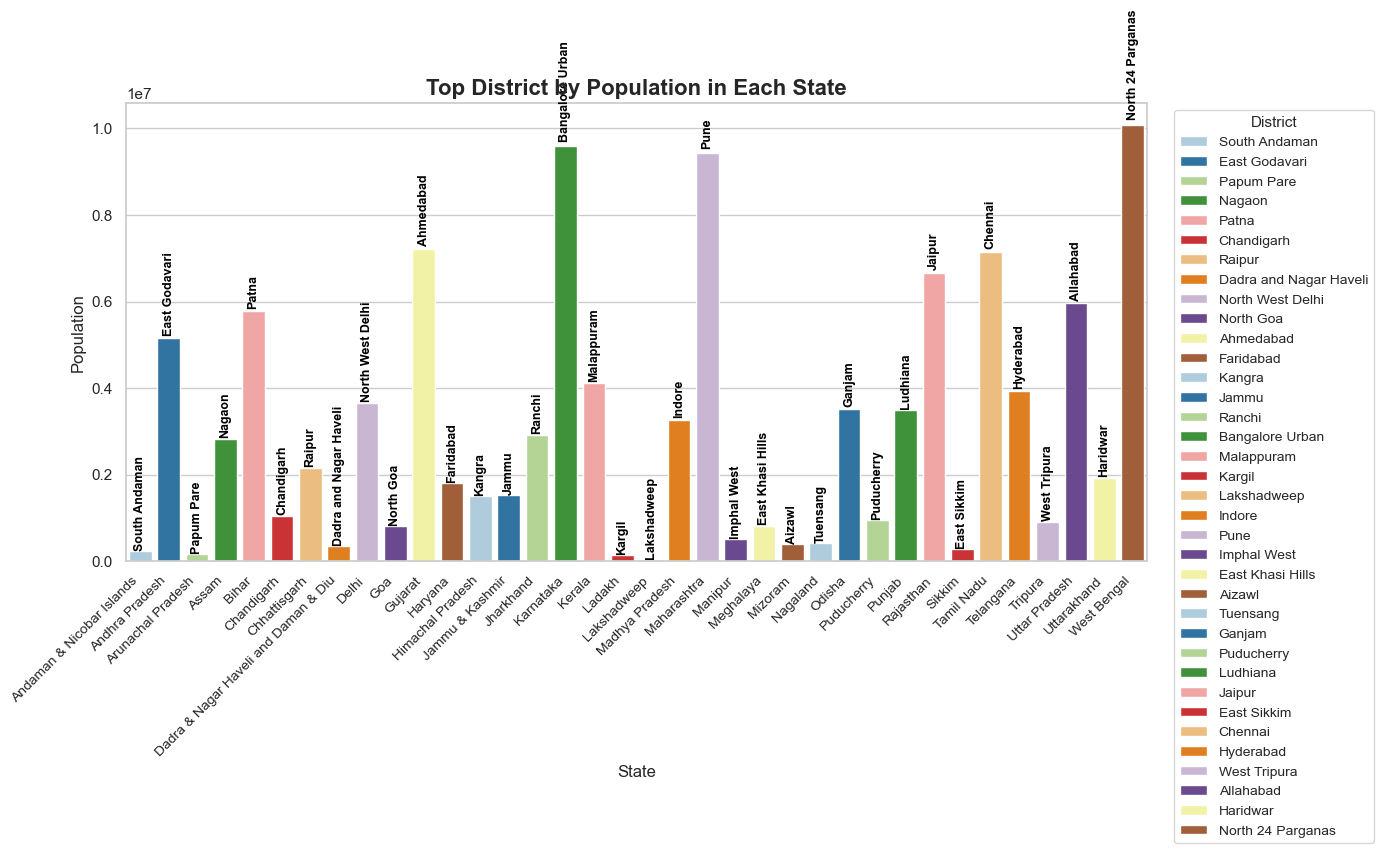

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 8))

# Bar chart
ax = sns.barplot(
    data=top_dis,
    x="State",
    y="Population",
    hue="District",
    dodge=False,
    palette="Paired"
)

# Titles and labels
plt.title("Top District by Population in Each State", fontsize=16, weight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Population", fontsize=12)

# Legend formatting
plt.legend(
    title="District",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

# Annotate bars with district names
for bar, district in zip(ax.patches, top_dis["District"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.01 * bar.get_height()),  # slight offset
        district,
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=90,
        color="black",
        weight="semibold"
    )

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right", fontsize=10)

# Tight layout for professional spacing
plt.tight_layout()
plt.show()


### 2.5: Calculate the average transaction value (ATV) for each state

In [42]:
# 1. Compute the average transaction value for each state. Display the results in a tabular format.


In [43]:
txn_sheet.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [44]:
total_txn_amount = txn_sheet.groupby("State").agg(
    total_amount = ("Amount (INR)", "sum"),
    total_transaction = ("Transactions","sum")
)
total_txn_amount.head()

,total_amount,total_transaction
State,,
Andaman & Nicobar Islands,3.641818e+09,1223565
Andhra Pradesh,3.187847e+12,1781091169
Arunachal Pradesh,2.225183e+10,8043799
Assam,2.814087e+11,123577981
Bihar,1.639579e+12,713643889


In [45]:
print("Average of ATV of each state")
total_txn_amount["Average_txn_value"] = round(total_txn_amount["total_amount"] / total_txn_amount["total_transaction"],2)
total_txn_amount.head()

Average of ATV of each state


,total_amount,total_transaction,Average_txn_value
State,,,
Andaman & Nicobar Islands,3.641818e+09,1223565,2976.40
Andhra Pradesh,3.187847e+12,1781091169,1789.83
Arunachal Pradesh,2.225183e+10,8043799,2766.33
Assam,2.814087e+11,123577981,2277.18
Bihar,1.639579e+12,713643889,2297.47


2. Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.

In [46]:
print("Top 5 States with highest ATV")

total_txn_amount.sort_values("Average_txn_value", ascending = False).head()

Top 5 States with highest ATV


,total_amount,total_transaction,Average_txn_value
State,,,
Ladakh,6.606978e+09,1880109,3514.15
Andaman & Nicobar Islands,3.641818e+09,1223565,2976.40
Mizoram,6.317141e+09,2162776,2920.85
Manipur,3.579325e+10,12318043,2905.76
Nagaland,1.638757e+10,5864977,2794.14


In [47]:
print("Top 5 States with lowest ATV")

total_txn_amount.sort_values("Average_txn_value", ascending = True).head()

Top 5 States with lowest ATV


,total_amount,total_transaction,Average_txn_value
State,,,
Karnataka,4.361396e+12,2981044533,1463.04
Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,12462185,1497.23
Maharashtra,4.290995e+12,2833670154,1514.29
West Bengal,1.452707e+12,942286041,1541.68
Delhi,1.649942e+12,1011031124,1631.94


###  2.6: Analyze app usage trends

In [48]:
# 1. Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.

In [49]:
total_state = txn_sheet.groupby(["State", "Year","Quarter"])["App Opens"].sum().reset_index()
total_state

,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
...,...,...,...,...
499,West Bengal,2020,2,198589332
500,West Bengal,2020,3,246554831
501,West Bengal,2020,4,291721919
502,West Bengal,2021,1,316832674


In [50]:
# 2.	Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.

In [51]:
selected_state = "Madhya Pradesh"
selected_state_mp = total_state[total_state["State"] == selected_state].copy()

In [52]:
selected_state_mp["year_quarter"] = selected_state_mp["Year"].astype(str) + " Q"+ selected_state_mp["Quarter"].astype(str)

In [53]:
selected_state_mp

,State,Year,Quarter,App Opens,year_quarter
266,Madhya Pradesh,2018,1,0,2018 Q1
267,Madhya Pradesh,2018,2,0,2018 Q2
268,Madhya Pradesh,2018,3,0,2018 Q3
269,Madhya Pradesh,2018,4,0,2018 Q4
270,Madhya Pradesh,2019,1,0,2019 Q1
271,Madhya Pradesh,2019,2,50642151,2019 Q2
272,Madhya Pradesh,2019,3,192353380,2019 Q3
273,Madhya Pradesh,2019,4,237844976,2019 Q4
274,Madhya Pradesh,2020,1,262452480,2020 Q1
275,Madhya Pradesh,2020,2,253770044,2020 Q2


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'No.of App opens over a year and quarter in Madhya Pradesh')

Text(0.5, 0, 'Year With Quarter')

Text(0, 0.5, 'App Opens in number')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2018 Q1'),
  Text(1, 0, '2018 Q2'),
  Text(2, 0, '2018 Q3'),
  Text(3, 0, '2018 Q4'),
  Text(4, 0, '2019 Q1'),
  Text(5, 0, '2019 Q2'),
  Text(6, 0, '2019 Q3'),
  Text(7, 0, '2019 Q4'),
  Text(8, 0, '2020 Q1'),
  Text(9, 0, '2020 Q2'),
  Text(10, 0, '2020 Q3'),
  Text(11, 0, '2020 Q4'),
  Text(12, 0, '2021 Q1'),
  Text(13, 0, '2021 Q2')])

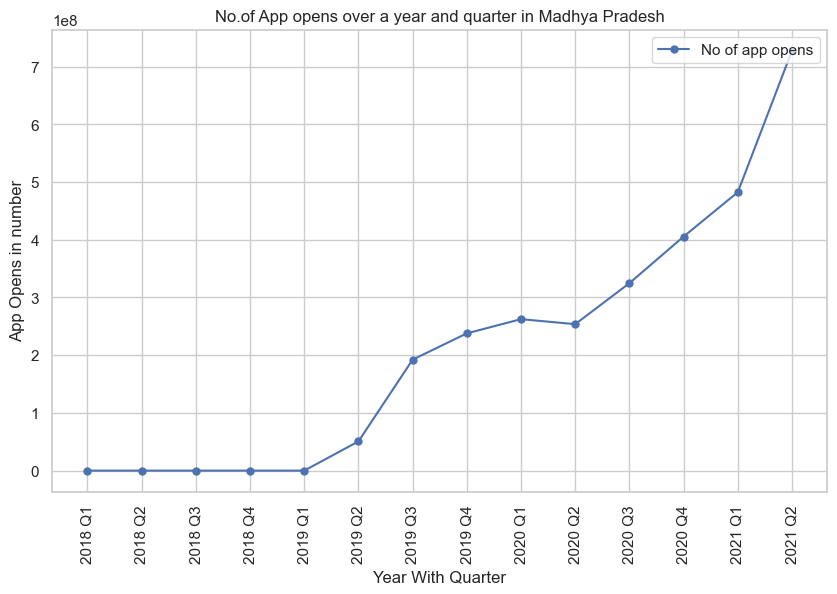

In [54]:
plt.figure(figsize = (10,6))
plt.plot(selected_state_mp["year_quarter"], selected_state_mp["App Opens"], marker = "o", markersize = 5,label = "No of app opens")
plt.title("No.of App opens over a year and quarter in Madhya Pradesh")
plt.xlabel("Year With Quarter")
plt.ylabel("App Opens in number")
plt.legend(loc = "upper right")


plt.xticks(rotation = 90)





### 2.7: Distribution of transaction types

In [55]:
# 1. Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.

In [56]:
txnsplit_sheet[["Year", "Quarter"]].value_counts()

Year  Quarter
2018  2          180
      4          180
2019  4          180
2020  2          180
      3          180
      4          180
2021  1          180
      2          180
2018  1          179
      3          179
2019  1          179
      2          179
      3          179
2020  1          179
Name: count, dtype: int64

In [57]:
latest_year = txnsplit_sheet["Year"].max()
latest_year_data = txnsplit_sheet[txnsplit_sheet["Year"] == latest_year]    # latest year data extract
latest_quar = latest_year_data["Quarter"].max()
new_data = latest_year_data[latest_year_data["Quarter"] == latest_quar]   # latest quarter data
# latest_quarter.groupby(["State","Transaction Type"])["Transactions"].sum()
new_data

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
65,Andaman & Nicobar Islands,2021,2,Peer-to-peer payments,132772,7.483820e+08,5636.595402
66,Andaman & Nicobar Islands,2021,2,Recharge & bill payments,120911,4.369196e+07,361.356380
67,Andaman & Nicobar Islands,2021,2,Merchant payments,85143,1.037074e+08,1218.037989
68,Andaman & Nicobar Islands,2021,2,Financial Services,960,2.038522e+06,2123.459910
69,Andaman & Nicobar Islands,2021,2,Others,1628,1.327080e+06,815.159740
...,...,...,...,...,...,...,...
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630


<BarContainer object of 5 artists>

Text(0.5, 1.0, 'No. of transaction via different transaction types')

Text(0.5, 0, 'Transaction Types')

Text(0, 0.5, 'No. of Transaction (in Millinons)')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Peer-to-peer payments'),
  Text(1, 0, 'Merchant payments'),
  Text(2, 0, 'Recharge & bill payments'),
  Text(3, 0, 'Financial Services'),
  Text(4, 0, 'Others')])

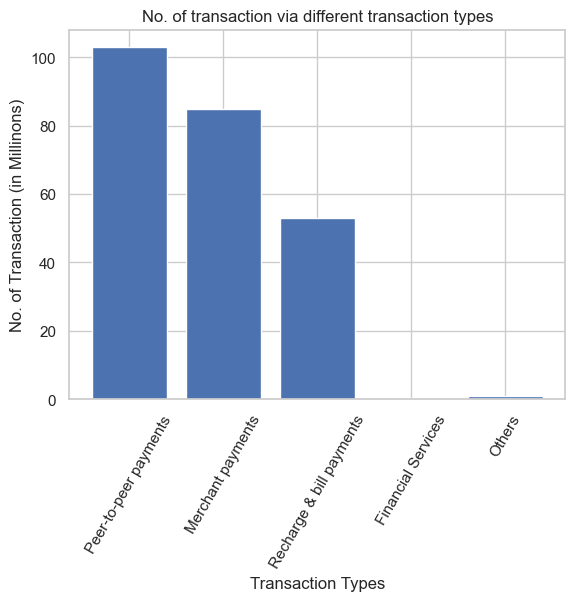

In [58]:
selected_state = "Uttar Pradesh"
selected_data = new_data[new_data["State"] == selected_state]

plt.bar(selected_data["Transaction Type"], selected_data["Transactions"]/ 1_000_000)
plt.title("No. of transaction via different transaction types")
plt.xlabel("Transaction Types")
plt.ylabel("No. of Transaction (in Millinons)")
plt.xticks(rotation = 60)
plt.show()


### 2.8: Find unique mapping between district name and district code

In [59]:
# 1.	Identify the unique mapping between district names and district codes from the
#       dataset. [hint: you can use drop_duplicates()]
# 2.	Create a CSV file containing the unique district name and district code mappings.
# 3.	Export the CSV file.


In [60]:
unique_mapping = district_sheet[["District", "Code"]].drop_duplicates()
unique_mapping

unique_mapping.to_csv("District and their code", index = False)
print("File successfully created")

,District,Code
0,Anantapur,AP01
1,Chittoor,AP02
2,East Godavari,AP03
3,Guntur,AP04
4,YSR,AP13
...,...,...
737,West Delhi,DL11
738,Karaikal,PY01
739,Mahé,PY02
740,Puducherry,PY03


File successfully created


#  Task 3: Data Quality Checks

#### 3.1: Ensure data consistency across state and district levels

In [61]:
# 1.	For each state, calculate the total number of transactions, total transaction amount, and total 
         # registered users by summing up the values from the district level data.
# 2.	Compare the results with the corresponding values at the state level to ensure they match.
# 3.	Display any discrepancies found between the district-level and state-level data.


In [62]:
district_txn_sheet.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0


In [63]:

print("District level data")

district_data = district_txn_sheet.groupby("State").agg(
    total_txn = ("Transactions", "sum"),
    total_amount = ("Amount (INR)", "sum"),
    total_user = ("Registered Users", "sum"))

district_data.head()

District level data


,total_txn,total_amount,total_user
State,,,
Andaman & Nicobar Islands,1223565,3.641818e+09,408396
Andhra Pradesh,1781091169,3.860292e+12,158007957
Arunachal Pradesh,8043799,2.225183e+10,1862214
Assam,123577981,2.814087e+11,26860751
Bihar,713643889,1.639579e+12,115284760


In [64]:
txn_sheet[txn_sheet["State"] == "Bihar"].head(20)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
56,Bihar,2018,1,5824302,6.045758e+09,1038.022783,2133804,0
57,Bihar,2018,2,8632378,1.350613e+10,1564.589863,3005872,0
58,Bihar,2018,3,14367804,2.013580e+10,1401.453164,3784535,0
59,Bihar,2018,4,15732401,2.839800e+10,1805.064413,4776665,0
60,Bihar,2019,1,26356234,4.150283e+10,1574.687321,5745117,0
61,Bihar,2019,2,29960479,6.313244e+10,2107.190552,6589759,39607022
62,Bihar,2019,3,32139900,6.769278e+10,2106.191471,7380265,126521298
63,Bihar,2019,4,43530314,9.331343e+10,2143.642395,8342274,163998097
64,Bihar,2020,1,45081815,1.092569e+11,2423.523843,9351234,183868505
65,Bihar,2020,2,53386742,1.288065e+11,2412.706204,10603767,218435035


In [65]:
print("State level data")

state_data = txn_sheet.groupby("State").agg(
    total_txn_s = ("Transactions", "sum"),
    total_amount_s = ("Amount (INR)", "sum"),
    total_user_s = ("Registered Users", "sum"))

state_data.head()

State level data


,total_txn_s,total_amount_s,total_user_s
State,,,
Andaman & Nicobar Islands,1223565,3.641818e+09,408396
Andhra Pradesh,1781091169,3.187847e+12,158007957
Arunachal Pradesh,8043799,2.225183e+10,1862214
Assam,123577981,2.814087e+11,26860751
Bihar,713643889,1.639579e+12,115284760


In [66]:
# merged Data of state level and district level data
merged_data = district_data.merge(state_data, on = "State")
merged_data.head()

,total_txn,total_amount,total_user,total_txn_s,total_amount_s,total_user_s
State,,,,,,
Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396
Andhra Pradesh,1781091169,3.860292e+12,158007957,1781091169,3.187847e+12,158007957
Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214
Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751
Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760


In [67]:
merged_data["compare_txn"] = merged_data["total_txn"] == merged_data["total_txn_s"]
merged_data["compare_amount"] = merged_data["total_amount"].round(1) ==  merged_data["total_amount_s"].round(1)

# merged_data["compare_amount"] = np.isclose(merged_data["total_amount"],  merged_data["total_amount_s"])

merged_data["compare_user"] = merged_data["total_user"] == merged_data["total_user_s"]

discrepencies = merged_data[(~merged_data["compare_txn"]) |
    (~merged_data["compare_amount"]) |
    (~merged_data["compare_user"])]

print("Discrepencies between District level data and State level data")

discrepencies
print("-----------------------------------------------------")
print("Discrepencies found in transaction amount in Andhra Pradesh")

Discrepencies between District level data and State level data


,total_txn,total_amount,total_user,total_txn_s,total_amount_s,total_user_s,compare_txn,compare_amount,compare_user
State,,,,,,,,,
Andhra Pradesh,1781091169,3.860292e+12,158007957,1781091169,3.187847e+12,158007957,True,False,True


-----------------------------------------------------
Discrepencies found in transaction amount in Andhra Pradesh


In [68]:

diff = discrepencies["total_amount"] - discrepencies["total_amount_s"]
txnn_sheet = txn_sheet.copy()

idx = txnn_sheet[txnn_sheet["Amount (INR)"].isna()].index[0]

# Filled amount that are difference in sheet.

txnn_sheet.loc[idx, "Amount (INR)"] = diff.values[0]
txnn_sheet[txnn_sheet["State"] == "Andhra Pradesh"]

# filled ATV value 
txnn_sheet.loc[idx, "ATV (INR)"] = txnn_sheet.loc[idx, "Amount (INR)"] / txnn_sheet.loc[idx,"Transactions"]

txnn_sheet[txnn_sheet["State"] == "Andhra Pradesh"]


,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
14,Andhra Pradesh,2018,1,9039585,1.199628e+10,1327.082647,3336450,0
15,Andhra Pradesh,2018,2,12353918,2.288391e+10,1852.360868,4402540,0
16,Andhra Pradesh,2018,3,25626061,3.571804e+10,1393.817200,5427617,0
17,Andhra Pradesh,2018,4,30759548,5.147378e+10,1673.424441,6857409,0
18,Andhra Pradesh,2019,1,57264522,8.376060e+10,1462.696151,8283019,0
19,Andhra Pradesh,2019,2,56409015,1.136345e+11,2014.474437,9389003,81375251
20,Andhra Pradesh,2019,3,76288614,1.394479e+11,1827.899826,10458693,310953542
21,Andhra Pradesh,2019,4,107218103,2.009483e+11,1874.201370,11757883,411201518
22,Andhra Pradesh,2020,1,127677357,2.527372e+11,1979.499108,13022060,486513773
23,Andhra Pradesh,2020,2,144917855,3.025837e+11,2087.966936,14319675,494341698


,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
14,Andhra Pradesh,2018,1,9039585,1.199628e+10,1327.082647,3336450,0
15,Andhra Pradesh,2018,2,12353918,2.288391e+10,1852.360868,4402540,0
16,Andhra Pradesh,2018,3,25626061,3.571804e+10,1393.817200,5427617,0
17,Andhra Pradesh,2018,4,30759548,5.147378e+10,1673.424441,6857409,0
18,Andhra Pradesh,2019,1,57264522,8.376060e+10,1462.696151,8283019,0
19,Andhra Pradesh,2019,2,56409015,1.136345e+11,2014.474437,9389003,81375251
20,Andhra Pradesh,2019,3,76288614,1.394479e+11,1827.899826,10458693,310953542
21,Andhra Pradesh,2019,4,107218103,2.009483e+11,1874.201370,11757883,411201518
22,Andhra Pradesh,2020,1,127677357,2.527372e+11,1979.499108,13022060,486513773
23,Andhra Pradesh,2020,2,144917855,3.025837e+11,2087.966936,14319675,494341698


#### Filled the sheet differnce happend with amount to correct.

# Task 4: Data Merging and Advanced Analysis

#### 4.1: Ratio of users to population by state

In [69]:
# 1.	Merge the State_Txn and Users dataset with the District Demographics dataset to calculate the 
        #ratio of registered users to the population for each state. Display the results in a tabular format.
# 2.	Create a column chart depicting the ratio of users to population by state.


In [70]:
print("Population data extracted from district demographics")

population_data = district_sheet.groupby("State")["Population"].sum().reset_index()

population_data.head()
population_data.shape

Population data extracted from district demographics


,State,Population
0,Andaman & Nicobar Islands,380581
1,Andhra Pradesh,49378776
2,Arunachal Pradesh,1606047
3,Assam,34461385
4,Bihar,103817951


(36, 2)

In [71]:
state_data = txnn_sheet["Year"].max()

ext_data = txnn_sheet[txn_sheet["Year"] == state_data]        # latest year data extracted

latest_quarter = ext_data["Quarter"].max()                       # from latest year data extracted latest quarter data

latest_data = ext_data[ext_data["Quarter"] == latest_quarter]

latest_data.head()              # here we extracted total register user

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
13,Andaman & Nicobar Islands,2021,2,341414,8.991470e+08,2633.597381,62095,2248223
27,Andhra Pradesh,2021,2,352767134,8.507375e+11,2411.612129,19620905,1044705436
41,Arunachal Pradesh,2021,2,1568338,4.456426e+09,2841.495658,270572,13025849
55,Assam,2021,2,25432905,5.919247e+10,2327.397259,3617056,102003890
69,Bihar,2021,2,155603622,3.745803e+11,2407.272083,14972134,371198660


In [72]:
overall_data = population_data.merge(latest_data, on = "State")

overall_data["ratio_of_registered_user"] = overall_data["Registered Users"]/overall_data["Population"]

print("Table shows ratio of registered users of each state")
overall_data[["State","Population","Registered Users", "ratio_of_registered_user"]].head()

Table shows ratio of registered users of each state


,State,Population,Registered Users,ratio_of_registered_user
0,Andaman & Nicobar Islands,380581,62095,0.163158
1,Andhra Pradesh,49378776,19620905,0.397355
2,Arunachal Pradesh,1606047,270572,0.168471
3,Assam,34461385,3617056,0.104960
4,Bihar,103817951,14972134,0.144215


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 36 artists>

Text(0.5, 1.0, 'Ratio of registered users from population of each state')

Text(0.5, 0, 'State')

Text(0, 0.5, 'Ratio of registered users')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'Andaman & Nicobar Islands'),
  Text(1, 0, 'Andhra Pradesh'),
  Text(2, 0, 'Arunachal Pradesh'),
  Text(3, 0, 'Assam'),
  Text(4, 0, 'Bihar'),
  Text(5, 0, 'Chandigarh'),
  Text(6, 0, 'Chhattisgarh'),
  Text(7, 0, 'Dadra & Nagar Haveli and Daman & Diu'),
  Text(8, 0, 'Delhi'),
  Text(9, 0, 'Goa'),
  Text(10, 0, 'Gujarat'),
  Text(11, 0, 'Haryana'),
  Text(12, 0, 'Himachal Pradesh'),
  Text(13, 0, 'Jammu & Kashmir'),
  Text(14, 0, 'Jharkhand'),
  Text(15, 0, 'Karnataka'),
  Text(16, 0, 'Kerala'),
  Text(17, 0, 'Ladakh'),
  Text(18, 0, 'Lakshadweep'),
  Text(19, 0, 'Madhya Pradesh'),
  Text(20, 0, 'Maharashtra'),
  Text(21, 0, 'Manipur'),
  Text(22, 0, 'Meghalaya'),
  Text(23, 0, 'Mizoram'),
  Text(24, 0, 'Nagaland'),
  Text(25, 0, 'Odisha'),
  Text(26, 0, 'Puducherry'),


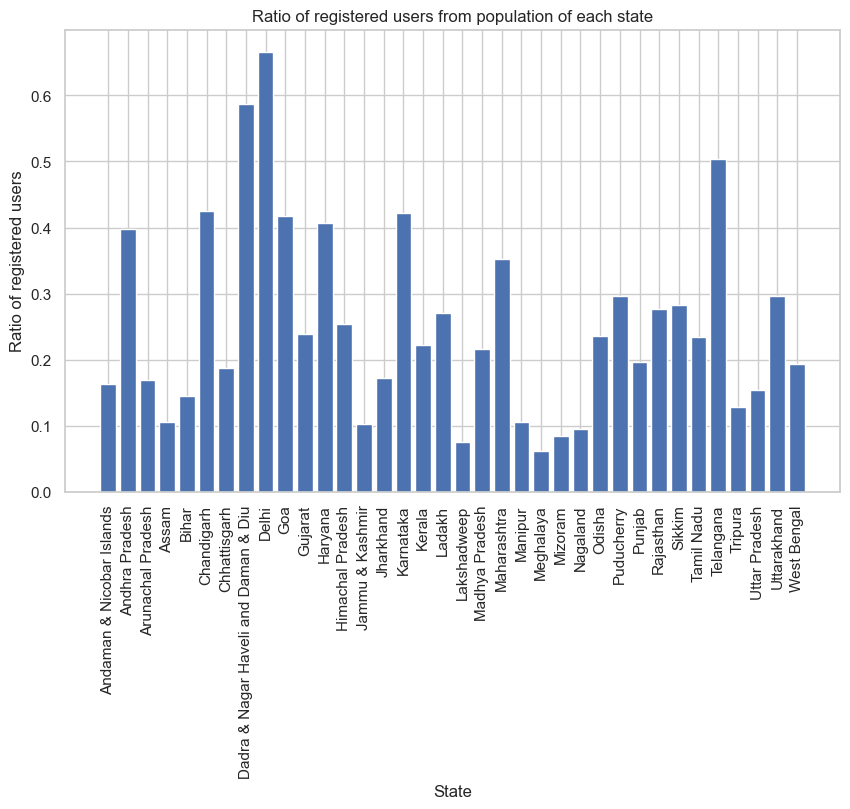

In [73]:
plt.figure(figsize = (10,6))
plt.bar(overall_data["State"],overall_data["ratio_of_registered_user"])
plt.title("Ratio of registered users from population of each state")
plt.xlabel("State")
plt.ylabel("Ratio of registered users")
plt.xticks(rotation = 90)


### 4.2: Correlate population density with transaction volume

In [74]:
# 1.	Merge the District_Txn and Users dataset with the District Demographics dataset.
# 2.	Calculate the correlation between population density and transaction volume.
# 3.	Create a scatter plot to visualize the correlation between population density and transaction volume.


In [75]:
transaction_data = txnn_sheet.groupby("State")["Transactions"].sum().reset_index()
transaction_data.head()           # this data contains transaction 
population_data.head()                # this data have population of each state

combine_data = transaction_data.merge(population_data, on ="State")
combine_data.head()
corr_matrix = combine_data[["Population", "Transactions"]].corr()
corr_matrix

,State,Transactions
0,Andaman & Nicobar Islands,1223565
1,Andhra Pradesh,1781091169
2,Arunachal Pradesh,8043799
3,Assam,123577981
4,Bihar,713643889


,State,Population
0,Andaman & Nicobar Islands,380581
1,Andhra Pradesh,49378776
2,Arunachal Pradesh,1606047
3,Assam,34461385
4,Bihar,103817951


,State,Transactions,Population
0,Andaman & Nicobar Islands,1223565,380581
1,Andhra Pradesh,1781091169,49378776
2,Arunachal Pradesh,8043799,1606047
3,Assam,123577981,34461385
4,Bihar,713643889,103817951


,Population,Transactions
Population,1.000000,0.617089
Transactions,0.617089,1.000000


<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation between Population density and Transactions volume')

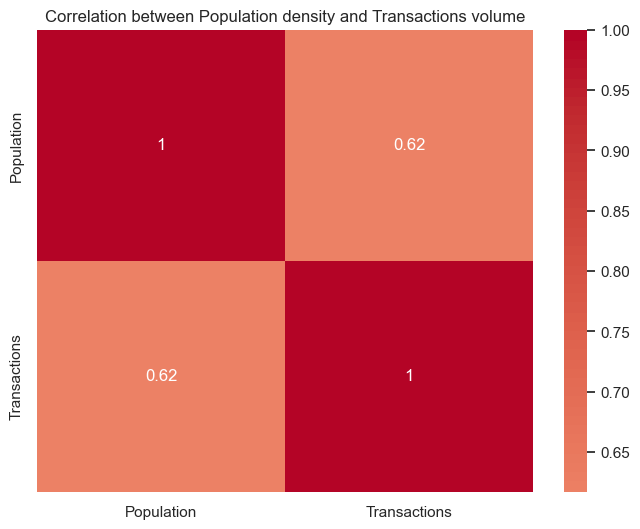

In [76]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = "coolwarm",
    center = 0)

plt.title("Correlation between Population density and Transactions volume")

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Population', ylabel='Transactions'>

Text(0.5, 1.0, 'Correlation: Population Density vs Transaction Volume')

Text(0.5, 0, 'Population Density')

Text(0, 0.5, 'Transaction Volume')

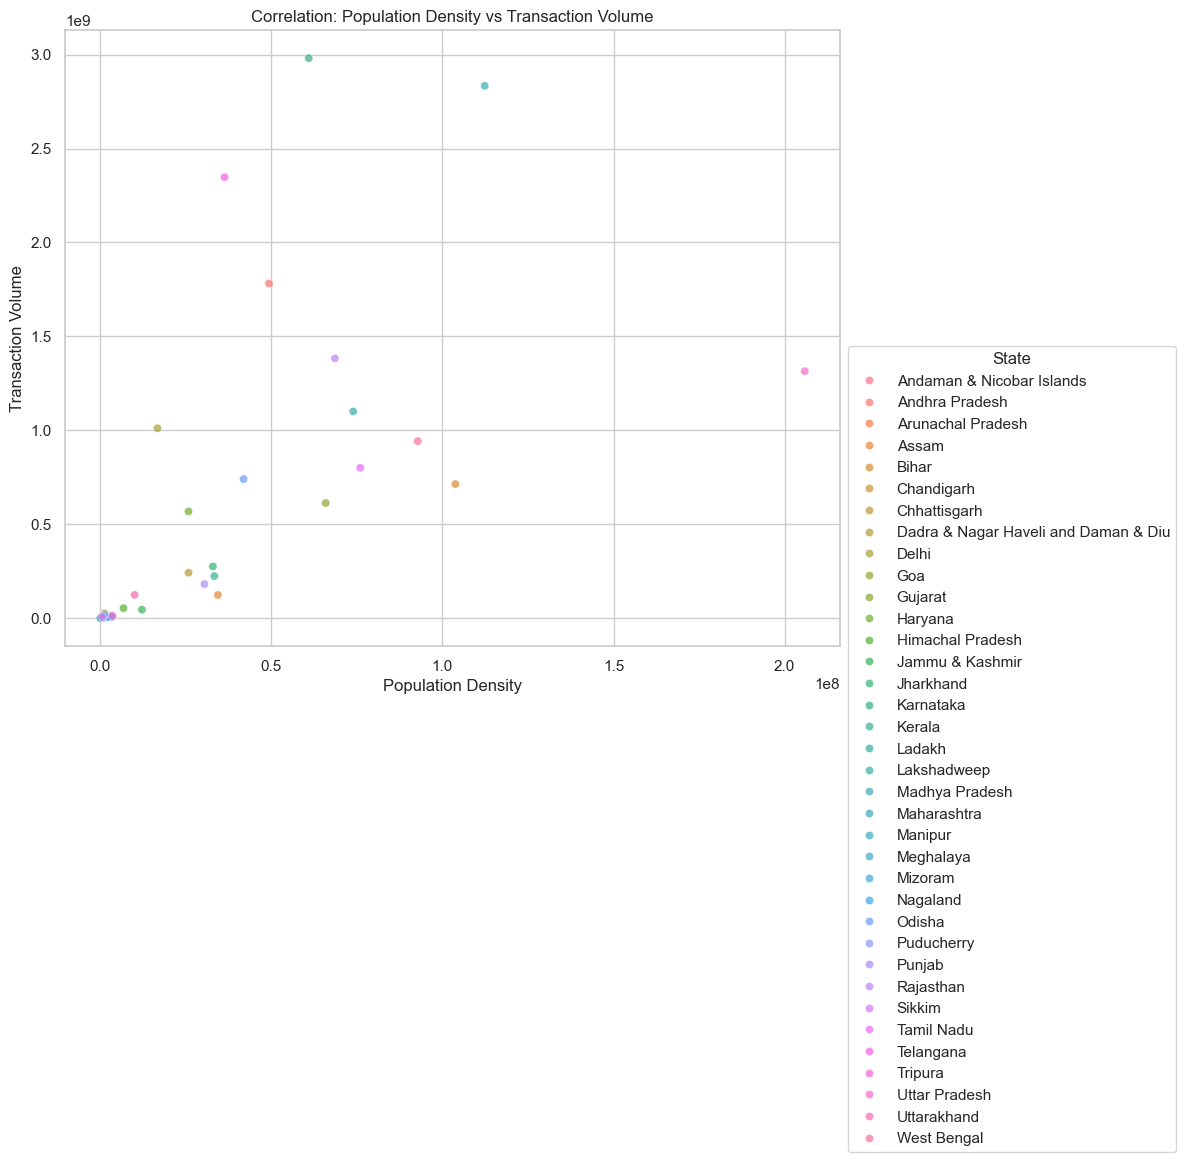

In [77]:

plt.figure(figsize=(10,8))
sns.scatterplot(
    data=combine_data,
    x="Population",
    y="Transactions",
    hue="State",       
    alpha=0.7
)


plt.title("Correlation: Population Density vs Transaction Volume")
plt.xlabel("Population Density")
plt.ylabel("Transaction Volume")
plt.legend(title="State", bbox_to_anchor=(1, .5), loc="upper left")
# plt.tight_layout()
plt.show()


## 4.3: Average transaction amount per user

1.	Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.
2.	Identify the top 5 states with the highest average transaction amount per user and the top 5 states with the lowest average transaction amount per user. Display the results.


In [78]:
txnn_sheet.head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [79]:
total_amount_per_state = txnn_sheet.groupby("State")[["Amount (INR)", "Registered Users"]].sum().reset_index()
total_amount_per_state.head()

,State,Amount (INR),Registered Users
0,Andaman & Nicobar Islands,3.641818e+09,408396
1,Andhra Pradesh,3.860292e+12,158007957
2,Arunachal Pradesh,2.225183e+10,1862214
3,Assam,2.814087e+11,26860751
4,Bihar,1.639579e+12,115284760


In [80]:

total_amount_per_state["amount_per_user"] = total_amount_per_state["Amount (INR)"] / total_amount_per_state["Registered Users"]
total_amount_per_state.head()

,State,Amount (INR),Registered Users,amount_per_user
0,Andaman & Nicobar Islands,3.641818e+09,408396,8917.369075
1,Andhra Pradesh,3.860292e+12,158007957,24430.998364
2,Arunachal Pradesh,2.225183e+10,1862214,11949.126662
3,Assam,2.814087e+11,26860751,10476.576498
4,Bihar,1.639579e+12,115284760,14221.991933


In [81]:
print("Top 5 States with highest transaction amount per user")
print("------------------------------------------------------------")
total_amount_per_state.sort_values(by="amount_per_user", ascending = False).head(5)



Top 5 States with highest transaction amount per user
------------------------------------------------------------


,State,Amount (INR),Registered Users,amount_per_user
31,Telangana,4.574246e+12,149224214,30653.509622
1,Andhra Pradesh,3.860292e+12,158007957,24430.998364
15,Karnataka,4.361396e+12,203098564,21474.282206
28,Rajasthan,2.625584e+12,149770064,17530.768707
8,Delhi,1.649942e+12,95374654,17299.587909


In [82]:
print("Top 5 States with lowest transaction amount per user")
print("------------------------------------------------------------")
total_amount_per_state.sort_values(by="amount_per_user", ascending = True).head(5)

Top 5 States with lowest transaction amount per user
------------------------------------------------------------


,State,Amount (INR),Registered Users,amount_per_user
18,Lakshadweep,1.921587e+08,34223,5614.898889
32,Tripura,2.097051e+10,3661575,5727.184275
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.815954
16,Kerala,3.729599e+11,51267042,7274.846690
12,Himachal Pradesh,9.786546e+10,13373980,7317.601442


# 4.4: Device brand usage ratio

 1.	Merge the State_DeviceData dataset with the State_Txn and Users dataset.
 2.	Calculate the ratio of users using each device brand to the total number of registered users in each state. Display the results in a tabular format.
 3. Create a bar chart depicting the device brand usage ratio for each state.


In [83]:
user_data = txnn_sheet.groupby("State")["Registered Users"].sum().reset_index()
user_data.head()

,State,Registered Users
0,Andaman & Nicobar Islands,408396
1,Andhra Pradesh,158007957
2,Arunachal Pradesh,1862214
3,Assam,26860751
4,Bihar,115284760


In [84]:
device_data = device_sheet.groupby(["State","Brand"])["Registered Users"].sum().reset_index()
device_data.head()

,State,Brand,Registered Users
0,Andaman & Nicobar Islands,Apple,9334
1,Andaman & Nicobar Islands,Huawei,11497
2,Andaman & Nicobar Islands,Lenovo,5362
3,Andaman & Nicobar Islands,Motorola,9491
4,Andaman & Nicobar Islands,OnePlus,15397


In [85]:
merged_data = device_data.merge(user_data, on = "State", how = "left")

merged_data = merged_data.rename(columns = {"Registered Users_x" : "Regisetered_Users_Device",
                                            "Registered Users_y" : "Registered_Users_Users"}
                                            )

# here we merged data
merged_data

,State,Brand,Regisetered_Users_Device,Registered_Users_Users
0,Andaman & Nicobar Islands,Apple,9334,408396
1,Andaman & Nicobar Islands,Huawei,11497,408396
2,Andaman & Nicobar Islands,Lenovo,5362,408396
3,Andaman & Nicobar Islands,Motorola,9491,408396
4,Andaman & Nicobar Islands,OnePlus,15397,408396
...,...,...,...,...
443,West Bengal,Others,17526532,144242183
444,West Bengal,Realme,9322038,144242183
445,West Bengal,Samsung,30516315,144242183
446,West Bengal,Vivo,18755122,144242183


In [86]:
merged_data["brand_ratio"] = merged_data["Regisetered_Users_Device"]/merged_data["Registered_Users_Users"]
merged_data.head()

,State,Brand,Regisetered_Users_Device,Registered_Users_Users,brand_ratio
0,Andaman & Nicobar Islands,Apple,9334,408396,0.022855
1,Andaman & Nicobar Islands,Huawei,11497,408396,0.028152
2,Andaman & Nicobar Islands,Lenovo,5362,408396,0.013129
3,Andaman & Nicobar Islands,Motorola,9491,408396,0.023240
4,Andaman & Nicobar Islands,OnePlus,15397,408396,0.037701


In [87]:
# made a column chart
state = "Uttar Pradesh"
sel_data = merged_data[merged_data["State"] == state]
sel_data



,State,Brand,Regisetered_Users_Device,Registered_Users_Users,brand_ratio
407,Uttar Pradesh,Apple,5050943,246200404,0.020516
408,Uttar Pradesh,Huawei,4396389,246200404,0.017857
409,Uttar Pradesh,Infinix,384335,246200404,0.001561
410,Uttar Pradesh,Lava,1104476,246200404,0.004486
411,Uttar Pradesh,Lenovo,3351692,246200404,0.013614
412,Uttar Pradesh,Micromax,752735,246200404,0.003057
413,Uttar Pradesh,Motorola,4983621,246200404,0.020242
414,Uttar Pradesh,OnePlus,876890,246200404,0.003562
415,Uttar Pradesh,Oppo,29567793,246200404,0.120096
416,Uttar Pradesh,Others,27665751,246200404,0.112371


<BarContainer object of 15 artists>

Text(0.5, 0, 'Brand')

Text(0, 0.5, 'Brand Ratio')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Apple'),
  Text(1, 0, 'Huawei'),
  Text(2, 0, 'Infinix'),
  Text(3, 0, 'Lava'),
  Text(4, 0, 'Lenovo'),
  Text(5, 0, 'Micromax'),
  Text(6, 0, 'Motorola'),
  Text(7, 0, 'OnePlus'),
  Text(8, 0, 'Oppo'),
  Text(9, 0, 'Others'),
  Text(10, 0, 'Realme'),
  Text(11, 0, 'Samsung'),
  Text(12, 0, 'Tecno'),
  Text(13, 0, 'Vivo'),
  Text(14, 0, 'Xiaomi')])

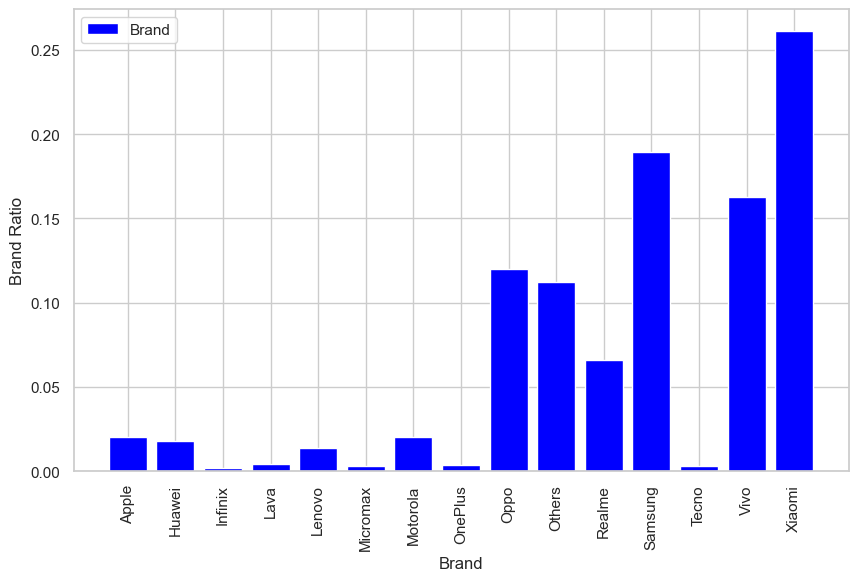

In [88]:


fig,  ax = plt.subplots(figsize = (10,6))
ax.bar(
    sel_data["Brand"],
    sel_data["brand_ratio"],
    color = "blue",
    label = "Brand"
)

ax.set_xlabel("Brand")
ax.set_ylabel("Brand Ratio")
ax.legend()
ax.grid(True)
plt.xticks(rotation = 90)
plt.show()

# Task 5: Data Visualization

5.1: Plot the total transactions and amount over time for a selected state

1.	Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state.


In [89]:
txnn_sheet

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0
...,...,...,...,...,...,...,...,...
499,West Bengal,2020,2,57676797,1.000994e+11,1735.523418,13222022,198589332
500,West Bengal,2020,3,79954504,1.568134e+11,1961.282329,14448366,246554831
501,West Bengal,2020,4,100340645,1.991655e+11,1984.893473,15662093,291721919
502,West Bengal,2021,1,118254052,2.429372e+11,2054.366877,16808799,316832674


In [90]:
selected_state = "West Bengal"

selected_data = txnn_sheet[txnn_sheet["State"] == selected_state].copy()

selected_data["year_quarter"] = selected_data["Year"].astype(str) + " Q" + selected_data["Quarter"].astype(str)
selected_data



,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,year_quarter
490,West Bengal,2018,1,11710225,1.062598e+10,907.410281,2604789,0,2018 Q1
491,West Bengal,2018,2,18082446,1.862918e+10,1030.235814,3833795,0,2018 Q2
492,West Bengal,2018,3,53705416,4.184393e+10,779.138070,4851740,0,2018 Q3
493,West Bengal,2018,4,36513548,4.048962e+10,1108.893039,6279278,0,2018 Q4
494,West Bengal,2019,1,47626388,5.016467e+10,1053.295762,7449425,0,2019 Q1
495,West Bengal,2019,2,47023535,5.710569e+10,1214.406597,8612795,49514201,2019 Q2
496,West Bengal,2019,3,66444829,7.054053e+10,1061.640668,9643222,176559011,2019 Q3
497,West Bengal,2019,4,96805838,8.820361e+10,911.139370,10885058,244326613,2019 Q4
498,West Bengal,2020,1,66250381,9.665331e+10,1458.909424,11960822,207068218,2020 Q1
499,West Bengal,2020,2,57676797,1.000994e+11,1735.523418,13222022,198589332,2020 Q2


Text(0.5, 0, 'Year_Quarter')

Text(0, 0.5, 'Value')

Text(0.5, 1.0, 'Transaction and Amount Over Time')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2018 Q1'),
  Text(1, 0, '2018 Q2'),
  Text(2, 0, '2018 Q3'),
  Text(3, 0, '2018 Q4'),
  Text(4, 0, '2019 Q1'),
  Text(5, 0, '2019 Q2'),
  Text(6, 0, '2019 Q3'),
  Text(7, 0, '2019 Q4'),
  Text(8, 0, '2020 Q1'),
  Text(9, 0, '2020 Q2'),
  Text(10, 0, '2020 Q3'),
  Text(11, 0, '2020 Q4'),
  Text(12, 0, '2021 Q1'),
  Text(13, 0, '2021 Q2')])

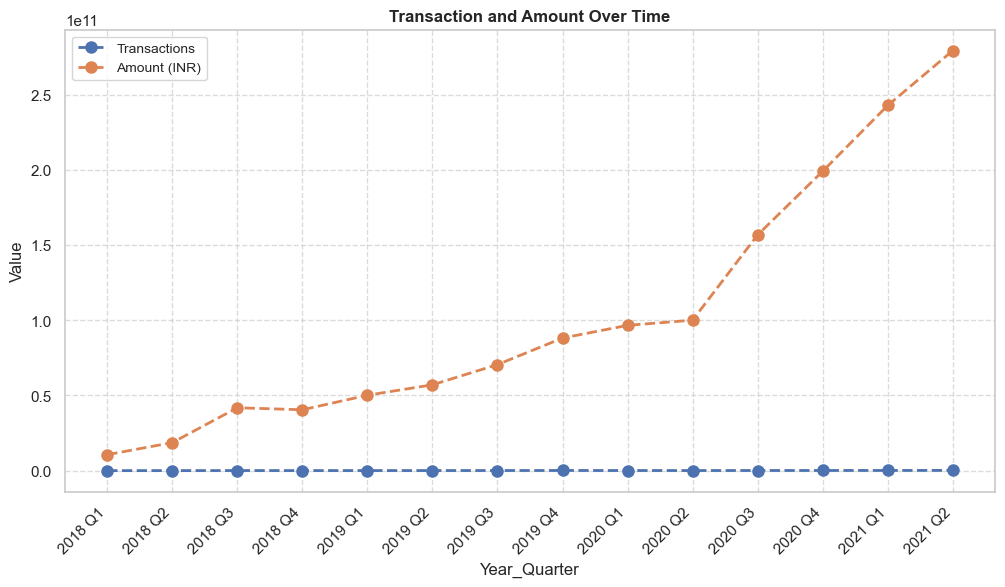

In [91]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize = (12,6))

ax.plot(
    selected_data["year_quarter"],
    selected_data["Transactions"],
    linestyle = "dashed",
    linewidth = 2,
    marker = "o",
    markersize = 8,
    label="Transactions"
)

ax.plot(
    selected_data["year_quarter"],
    selected_data["Amount (INR)"],
    linestyle = "dashed",
    linewidth = 2,
    marker = "o",
    markersize = 8,
    label="Amount (INR)"
)
ax.set_xlabel("Year_Quarter")
ax.set_ylabel("Value")
ax.set_title("Transaction and Amount Over Time", weight = "bold")
plt.xticks(rotation = 45, ha = "right")
ax.legend(fontsize=10, frameon=True)
ax.grid(True, linestyle="--", alpha=0.7)
plt.show()

5.2: Create a pie chart showing the distribution of transaction types for a specific quarter

1.	Create a pie chart showing the distribution of different transaction types for a selected state and quarter.


In [92]:
txnsplit_sheet.head()

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,6487.790112
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,1518.480432
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,321.255149
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05,721.444790


In [93]:
sel_state = "Rajasthan"

sel_data = txnsplit_sheet[txnsplit_sheet["State"] == sel_state]


sel_year = 2019
sel_quarter = 2

ext_data = sel_data[(sel_data["Year"] == sel_year) & (sel_data["Quarter"] == sel_quarter)]

ext_data

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
1979,Rajasthan,2019,2,Peer-to-peer payments,25257679,7.946646e+10,3146.229869
1980,Rajasthan,2019,2,Recharge & bill payments,14968290,5.709280e+09,381.424969
1981,Rajasthan,2019,2,Merchant payments,9026751,3.435472e+09,380.587896
1982,Rajasthan,2019,2,Financial Services,182685,3.413449e+07,186.848875
1983,Rajasthan,2019,2,Others,573881,4.619629e+08,804.980263


([<matplotlib.patches.Wedge at 0x25997f66e40>,
 [Text(-1.0998610285852706, -0.017484787655297932, 'Peer-to-peer payments'),
  Text(0.9086797701315849, -0.6199202169260253, 'Recharge & bill payments'),
  Text(0.6762668038823537, 0.8675616462054707, 'Merchant payments'),
  Text(0.0918295998883749, 1.0961602640966062, 'Financial Services'),
  Text(0.03964796391764594, 1.099285240034262, 'Others')],
 [Text(-0.49993683117512294, -0.00794763075240815, '50.5%'),
  Text(0.41303625915072034, -0.28178191678455694, '29.9%'),
  Text(0.3073940017647062, 0.39434620282066846, '18.1%'),
  Text(0.041740727221988586, 0.49825466549845726, '0.4%'),
  Text(0.018021801780748154, 0.4996751091064827, '1.1%')])

Text(0.5, 1.0, 'Transactions by Type')

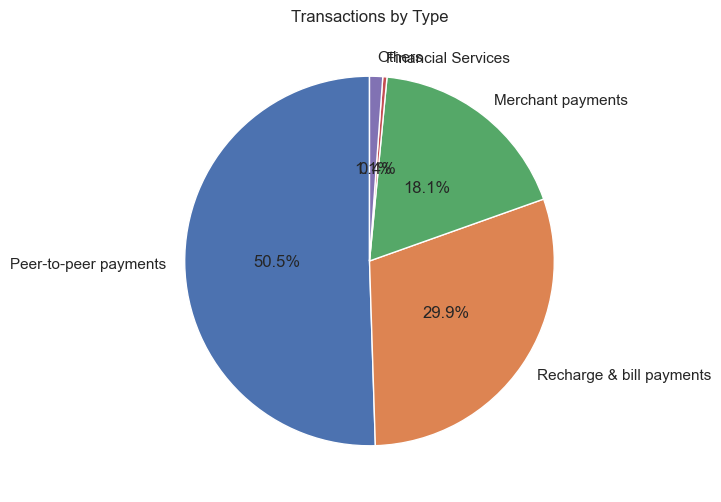

In [94]:
fig, ax = plt.subplots(figsize = (12,6))

ax.pie(
    ext_data["Transactions"],
    labels = ext_data["Transaction Type"],
    autopct = "%1.1f%%",
    startangle = 90,
    pctdistance = 0.5,
    labeldistance = 1.1
)
ax.set_title("Transactions by Type")
plt.show()

5.3: Visualize the population density of districts in a selected state

1.	Create a bar plot showing the population density of districts in a selected state.


In [95]:
sel_state = "Punjab"
data = district_sheet[district_sheet["State"] == sel_state]

sel_data = data.sort_values("Density", ascending = False)
sel_data.head()

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
458,Punjab,Ludhiana,Ludhiana,3487882,3744.0,975,PB12,Ludhiana
447,Punjab,Amritsar,Amritsar,2490891,2673.0,932,PB01,Amritsar
456,Punjab,Jalandhar,Jalandhar,2181753,2625.0,831,PB10,Jalandhar
466,Punjab,Sahibzada Ajit Singh Nagar,Mohali,986147,1188.0,830,PB19,Sas Nagar
463,Punjab,Pathankot,Pathankot,626154,929.0,674,PB16,Pathankot


<BarContainer object of 23 artists>

Text(0.5, 0, 'District')

Text(0, 0.5, 'Value')

Text(0.5, 1.0, 'Population Density of each district')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'Ludhiana'),
  Text(1, 0, 'Amritsar'),
  Text(2, 0, 'Jalandhar'),
  Text(3, 0, 'Sahibzada Ajit Singh Nagar'),
  Text(4, 0, 'Pathankot'),
  Text(5, 0, 'Gurdaspur'),
  Text(6, 0, 'Patiala'),
  Text(7, 0, 'Fatehgarh Sahib'),
  Text(8, 0, 'Kapurthala'),
  Text(9, 0, 'Rupnagar'),
  Text(10, 0, 'Shahid Bhagat Singh Nagar'),
  Text(11, 0, 'Hoshiarpur'),
  Text(12, 0, 'Tarn Taran'),
  Text(13, 0, 'Sangrur'),
  Text(14, 0, 'Moga'),
  Text(15, 0, 'Faridkot'),
  Text(16, 0, 'Barnala'),
  Text(17, 0, 'Bathinda'),
  Text(18, 0, 'Firozpur'),
  Text(19, 0, 'Fazilka'),
  Text(20, 0, 'Mansa'),
  Text(21, 0, 'Sri Muktsar Sahib'),
  Text(22, 0, 'Malerkotla')])

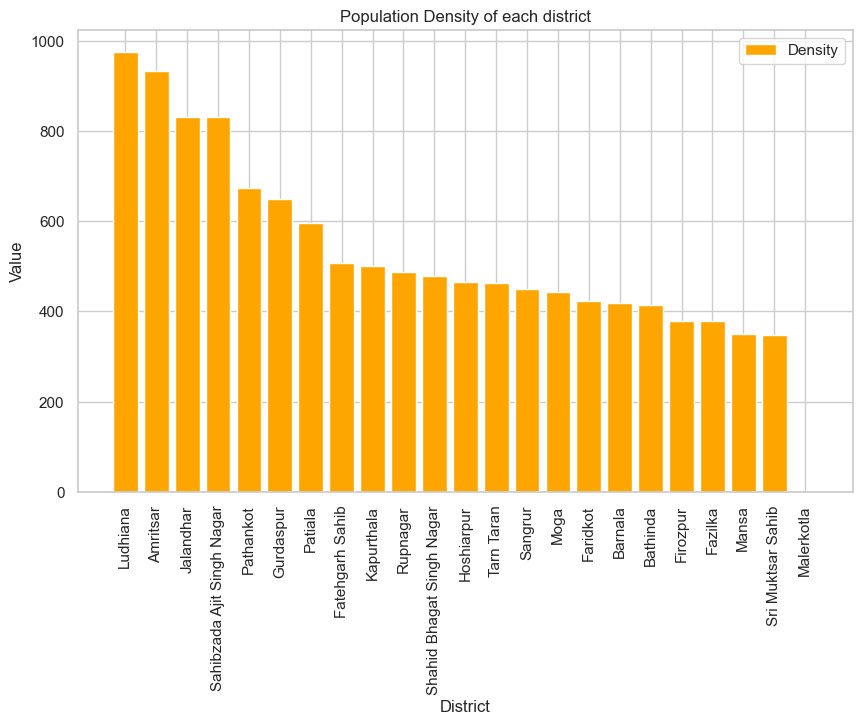

In [96]:

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(
    sel_data["District"],
    sel_data["Density"],
    color = "orange",
    label = "Density"
)

ax.set_xlabel("District")
ax.set_ylabel("Value")
plt.title("Population Density of each district")
ax.grid(True)
ax.legend()
plt.xticks(rotation = 90)
plt.show()

## Task 6: Insights and Conclusions [Advanced Section]

6.1: Identify any trends or patterns in the transaction data

1.	Analyze the transaction data to identify any noticeable trends or patterns. Summarize your findings. [hint: you can create line graph – at year or quarter and discuss your findings with interviewer]


In [97]:
# Overall Transaction Trend

yearly_data = txnn_sheet.groupby("Year")[["Transactions", "Amount (INR)"]].sum().reset_index()

yearly_data["ATV"] = round(yearly_data["Amount (INR)"] / yearly_data["Transactions"],2)
yearly_data

,Year,Transactions,Amount (INR),ATV
0,2018,1080202410,1.623045e+12,1502.54
1,2019,4079827215,6.276688e+12,1538.47
2,2020,7973974741,1.464116e+13,1836.12
3,2021,7398955928,1.376071e+13,1859.82


Text(0.5, 0, 'Year')

Text(0, 0.5, 'Transactions Value')

Text(0.5, 1.0, 'Yearly Trend of Transactions')

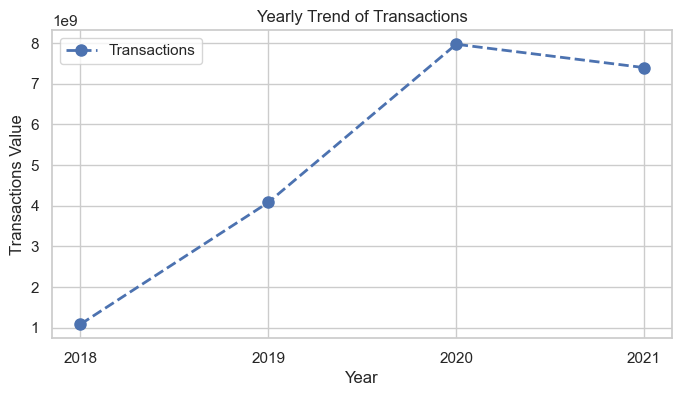

In [98]:
fig, ax = plt.subplots(figsize = (8,4))
ax.plot(
    yearly_data["Year"],
    yearly_data["Transactions"],
    linestyle = "dashed",
    linewidth = 2,
    marker = "o",
    markersize = 8,
    label = "Transactions"
)

ax.set_xlabel("Year")
ax.set_ylabel("Transactions Value")
ax.set_xticks([2018,2019,2020,2021])
ax.legend()
plt.title("Yearly Trend of Transactions")
plt.show()
    


Text(0.5, 0, 'Year')

Text(0, 0.5, 'Amount (INR)')

Text(0.5, 1.0, 'Yearly Trend of Amount')

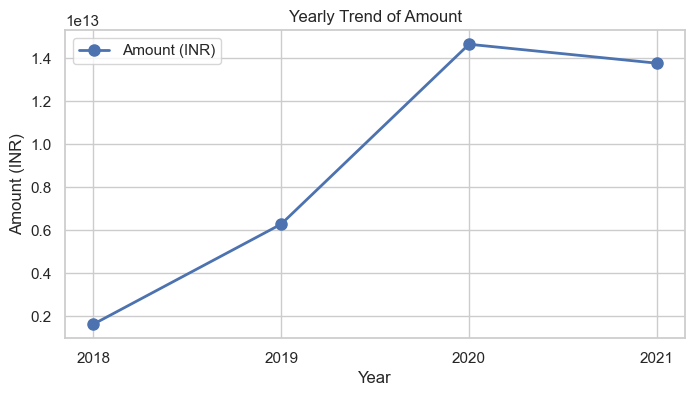

In [99]:
fig, ax = plt.subplots(figsize = (8,4))
ax.plot(
    yearly_data["Year"],
    yearly_data["Amount (INR)"],
    linestyle = "solid",
    linewidth = 2,
    marker = "o",
    markersize = 8,
    label = "Amount (INR)"
)

ax.set_xlabel("Year")
ax.set_ylabel("Amount (INR)")
ax.set_xticks([2018,2019,2020,2021])
ax.legend()
plt.title("Yearly Trend of Amount")
plt.show()

Text(0.5, 0, 'Year')

Text(0, 0.5, 'ATV Value')

Text(0.5, 1.0, 'Yearly Trend of Average Transaction Value')

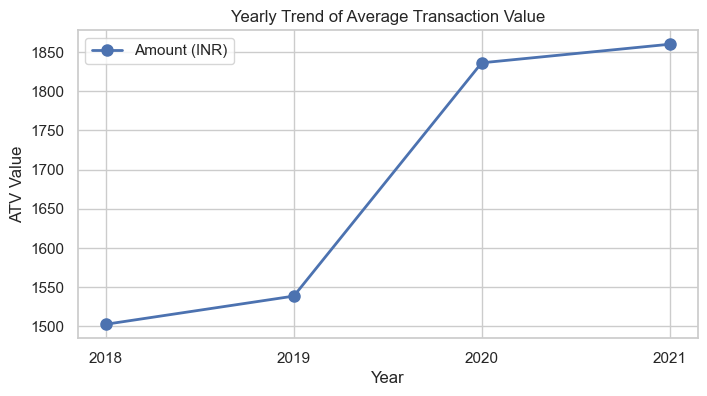

In [100]:
fig, ax = plt.subplots(figsize = (8,4))
ax.plot(
    yearly_data["Year"],
    yearly_data["ATV"],
    linestyle = "solid",
    linewidth = 2,
    marker = "o",
    markersize = 8,
    label = "Amount (INR)"
)

ax.set_xlabel("Year")
ax.set_ylabel("ATV Value")
ax.set_xticks([2018,2019,2020,2021])
ax.legend()
plt.title("Yearly Trend of Average Transaction Value")
plt.show()

In [101]:
# Added Year_Quarter
new_txn = txnn_sheet.copy()
new_txn["year_quarter"] = new_txn["Year"].astype(str) + " Q" + new_txn["Quarter"].astype(str)
new_txn.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,year_quarter
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,2018 Q1
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0,2018 Q2
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0,2018 Q3
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0,2018 Q4
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0,2019 Q1


Text(0.5, 0, 'Quarter')

Text(0, 0.5, 'Transactions Value')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2018 Q1'),
  Text(1, 0, '2018 Q2'),
  Text(2, 0, '2018 Q3'),
  Text(3, 0, '2018 Q4'),
  Text(4, 0, '2019 Q1'),
  Text(5, 0, '2019 Q2'),
  Text(6, 0, '2019 Q3'),
  Text(7, 0, '2019 Q4'),
  Text(8, 0, '2020 Q1'),
  Text(9, 0, '2020 Q2'),
  Text(10, 0, '2020 Q3'),
  Text(11, 0, '2020 Q4'),
  Text(12, 0, '2021 Q1'),
  Text(13, 0, '2021 Q2')])

Text(0.5, 1.0, 'Quarterly Trend')

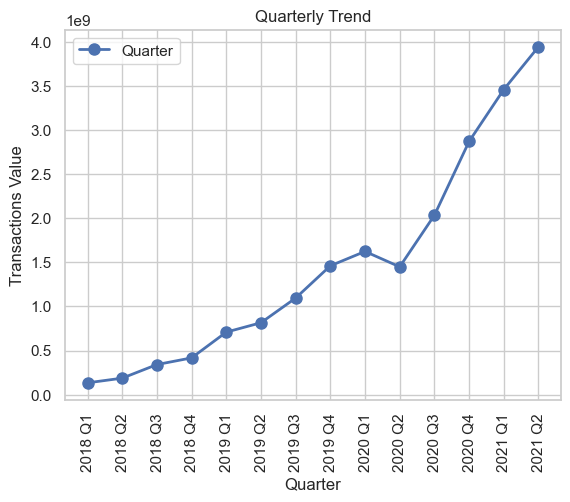

In [102]:
quarter_txn = new_txn.groupby("year_quarter")["Transactions"].sum().reset_index()

fig, ax = plt.subplots()
ax.plot(
    quarter_txn["year_quarter"],
    quarter_txn["Transactions"],
    linestyle = "solid",
    linewidth = 2,
    marker = "o",
    markersize = 8,
    label = "Quarter"
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Transactions Value")
plt.xticks(rotation = 90)
ax.legend()
plt.title("Quarterly Trend")
plt.show()

<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Registered Users vs Transactions')

Text(0.5, 0, 'Registered Users')

Text(0, 0.5, 'Transactions')

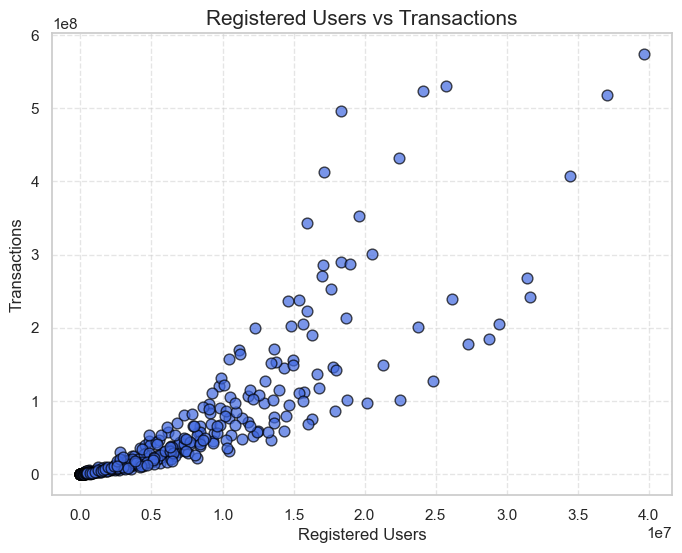

In [103]:

plt.figure(figsize=(8,6))
plt.scatter(
    txnn_sheet["Registered Users"],
    txnn_sheet["Transactions"],
    s=60,
    alpha=0.7,
    color="royalblue",
    edgecolor="black"
)

plt.title("Registered Users vs Transactions", fontsize=15)
plt.xlabel("Registered Users")
plt.ylabel("Transactions")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


There is a strong positive relationship between registered users and transaction volume. States with more users generally perform more transactions

In [104]:
# Top State by Transactions

txnn_sheet.groupby("State")["Transactions"].sum().sort_values(ascending = False).reset_index().head()

,State,Transactions
0,Karnataka,2981044533
1,Maharashtra,2833670154
2,Telangana,2347430243
3,Andhra Pradesh,1781091169
4,Rajasthan,1382918930


In [105]:
# Top state by Amount(INR)

txnn_sheet.groupby("State")["Amount (INR)"].sum().sort_values(ascending = False).reset_index().head()

,State,Amount (INR)
0,Telangana,4.574246e+12
1,Karnataka,4.361396e+12
2,Maharashtra,4.290995e+12
3,Andhra Pradesh,3.860292e+12
4,Rajasthan,2.625584e+12


In [106]:
# Average Transaction Value of each state
avg_value = txn_sheet.groupby("State")[["Transactions","Amount (INR)"]].sum()

avg_value["ATV"] = avg_value["Amount (INR)"] / avg_value["Transactions"]
avg_value["ATV"].sort_values(ascending = False).reset_index().head()


,State,ATV
0,Ladakh,3514.146494
1,Andaman & Nicobar Islands,2976.399178
2,Mizoram,2920.848685
3,Manipur,2905.757931
4,Nagaland,2794.140997


In [107]:
# Highest Growth State

growth = txn_sheet.groupby(["State","Year"])["Transactions"].sum().unstack().sort_values(by = 2020, ascending = False)
growth.head()

print("Karnataka and Telangana show the fastest transaction growth across the years.")

Year,2018,2019,2020,2021
State,,,,
Karnataka,99925678,610519200,1216153117,1054446538
Maharashtra,116301535,526225123,1099666770,1091476726
Telangana,67541293,439968715,931480581,908439654
Andhra Pradesh,77779112,297180254,763616699,642515104
Rajasthan,52782208,246343185,543585579,540207958


Karnataka and Telangana show the fastest transaction growth across the years.


<Axes: >

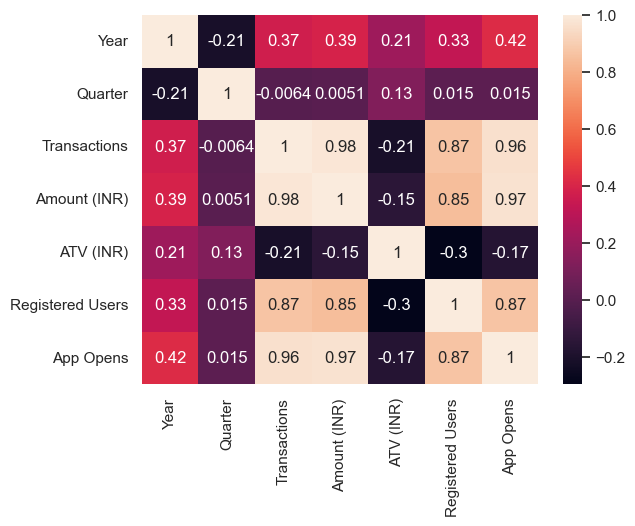

In [108]:
# Correlation Heatmap

sns.heatmap(txn_sheet.corr(numeric_only=True),annot=True)

### 6.2: Correlate demographic data with transaction data

1.	Find correlations between demographic data (e.g., population density) and transaction data (e.g., transaction volume). Summarize your findings. [Hint: you can use corr()]

In [109]:
district_txn_sheet.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0


In [110]:
dis_txn = district_txn_sheet.groupby(["State", "District"])[["Transactions","Amount (INR)", "Registered Users"]].sum()
dis_txn

Transactions  \
State                     District                                   
Andaman & Nicobar Islands Nicobars                           59387   
                          North And Middle Andaman          149394   
                          South Andaman                    1014784   
Andhra Pradesh            Anantapur                      124411535   
                          Chittoor                       181284289   
...                                                            ...   
West Bengal               Purba Bardhaman                 45668162   
                          Purba Medinipur                 43394953   
                          Purulia                         18265697   
                          South Twenty Four Parganas      44715760   
                          Uttar Dinajpur                  13040415   

                                                      Amount (INR)  \
State                     District                                   
Andaman & Nicobar Islands Nicobars                    2.290015e+08   
                          North And Middle Andaman    3.631200e+08   
                          South Andaman               3.049696e+09   
Andhra Pradesh            Anantapur                   2.795880e+11   
                          Chittoor                    3.533273e+11   
...                                                            ...   
West Bengal               Purba Bardhaman             5.185648e+10   
                          Purba Medinipur             7.362676e+10   
                          Purulia                     1.560582e+10   
                          South Twenty Four Parganas  6.959206e+10   
                          Uttar Dinajpur              2.603368e+10   

                                                      Registered Users  
State                     District                                      
Andaman & Nicobar Islands Nicobars                               12179  
                          North And Middle Andaman               50523  
                          South Andaman                         345694  
Andhra Pradesh            Anantapur                           11857400  
                          Chittoor                            15248543  
...                                                                ...  
West Bengal               Purba Bardhaman                      6445210  
                          Purba Medinipur                      7564653  
                          Purulia                              3566946  
                          South Twenty Four Parganas           9878400  
                          Uttar Dinajpur                       2981254  

[732 rows x 3 columns]

In [111]:
correl_data = district_sheet.merge(dis_txn, on = ["State","District"], how = "left")
correl_data.head()

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name,Transactions,Amount (INR),Registered Users
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur,124411535.0,2.795880e+11,11857400.0
1,Andhra Pradesh,Chittoor,Chittoor,4170468,15152.0,275,AP02,Chittoor,181284289.0,3.533273e+11,15248543.0
2,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.0,477,AP03,East Godavari,160754836.0,3.371513e+11,16117085.0
3,Andhra Pradesh,Guntur,Guntur,4889230,11391.0,429,AP04,Guntur,160872479.0,3.610819e+11,15627052.0
4,Andhra Pradesh,YSR,Kadapa,2884524,15359.0,188,AP13,YSR,NaN,NaN,NaN


<Figure size 640x480 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix')

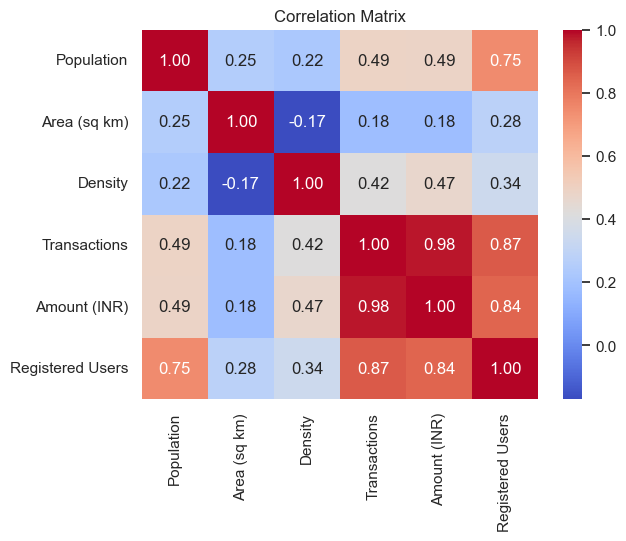

In [112]:
plt.figure()

sns.heatmap(
    correl_data.corr(numeric_only = True),
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)

plt.title("Correlation Matrix")
plt.show()

#### Key observations include:

1. Registered Users show a strong relationship with both transaction volume (0.87) and transaction amount (0.84).
2. Transactions and Transaction Amount are almost perfectly correlated (0.98), indicating that increasing transaction frequency directly increases payment value.
3. Population has a moderate positive impact on transactions (0.49) and a strong relationship with registered users (0.75).
4. Area has minimal influence on digital payment activity and should not be considered a major business drive

## 6.3: Summarize findings and insights

### Business Insights
1. Karnataka, Maharashtra, Telangana, Andhra Pradesh, and Rajasthan drive the highest transaction volumes and these are PhonePe's mature markets. Focus here should shift from acquisition to retention and fraud prevention.

2. High-volume, low-ATV states are Karnataka, Maharashtra, West Bengal show frequent small transactions and a sign of strong daily-use habits (recharges, small transfers). Great for engagement, lower per-transaction revenue.


3. Low-volume, high-ATV states (Ladakh, Andaman & Nicobar, Mizoram, Manipur, Nagaland) show fewer but larger transactions and a signal that merchant payment infrastructure is under-developed there. Strong opportunity for local merchant onboarding.


4. Peer-to-peer payments dominate ~50% of all transactions nationwide, with merchant payments second. Pushing merchant QR adoption can build stickier, higher-value daily usage.


5. User penetration vs population is highest in Delhi, Karnataka, Telangana, and Dadra & Nagar Haveli (urban, high smartphone density) while Assam, Bihar, and Jammu & Kashmir lag behind, marking them as priority markets for rural expansion.


6. Xiaomi is the most common device brand among PhonePe users in nearly every state and showing the core user base runs on budget/mid-range Android phones. Product decisions (app size, offline mode, low-end optimization) should reflect this.

 
7. Transactions and app opens grew sharply from 2019 onward, aligning with India's UPI adoption wave and the COVID-19 push toward cashless payments.


8. A data quality gap was found between state-level and district-level totals for Andhra Pradesh (~₹670 Bn mismatch)  flagged for data engineering review before using state totals for financial reporting and that gap filled so data credibility should maintain.